Assignment: Loan Approval Prediction Using Machine Learning

IMPORT STATEMENTS

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [129]:
from sklearn.model_selection import(
    train_test_split,
    cross_val_score,
    GridSearchCV,
    learning_curve
)

In [130]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [131]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

Question 1. Load the Loan Prediction dataset and perform an initial analysis.

Tasks:
1. Display the first 10 records.
2. Identify all features and the target variable.
3. Determine the number of records and attributes.
4. Check for missing values.
5. Describe the statistical properties of numerical features.


In [132]:
loan_df = pd.read_csv("Loan_prediction.csv")
loan_df.head(10)

print("Features:")
print(loan_df.columns.tolist())

target = "Loan_Status"

print("\nTarget Variable:")
print(target)

features = loan_df.drop(columns=[target]).columns.tolist()

print("\nInput Features:")
print(features)

rows, columns = loan_df.shape

print("\nNumber of Records:", rows)
print("Number of Attributes:", columns)

print("\nMissing Values in Each Column:")
print(loan_df.isnull().sum())

loan_df.select_dtypes(include=['number']).describe()

Features:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Target Variable:
Loan_Status

Input Features:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Number of Records: 614
Number of Attributes: 13

Missing Values in Each Column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


Question 2. Perform data preprocessing.

Tasks:
1. Handle missing values using appropriate techniques.
2. Convert categorical variables into numerical format.
3. Normalize or standardize numerical features (if required).
4. Create the final feature matrix and target variable.


In [133]:
categorical_cols = loan_df.select_dtypes(include='object').columns

for col in categorical_cols:
    loan_df[col].fillna(loan_df[col].mode()[0], inplace=True)

numerical_cols = loan_df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    loan_df[col].fillna(loan_df[col].median(), inplace=True)

print(loan_df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_2818/421022646.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_df[col].fillna(loan_df[col].mode()[0], inplace=True)
/tmp/ipykernel_2818/421022646.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

Question 3. Perform exploratory data analysis to understand factors affecting loan approval.

Create at least five visualizations, such as:
1. Loan approval distribution.
2. Applicant income vs loan approval.
3. Credit history vs loan approval.
4. Education level vs loan approval.
5. Property area vs loan approval.


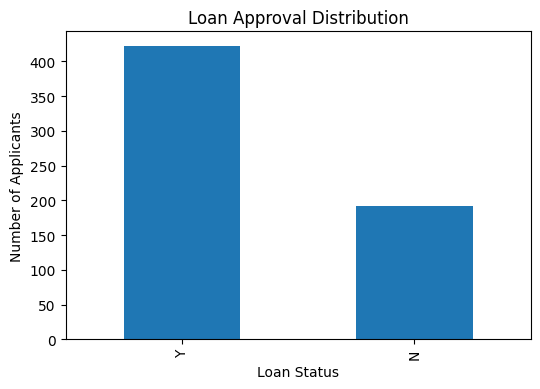

In [134]:
loan_df['Loan_Status'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.show()

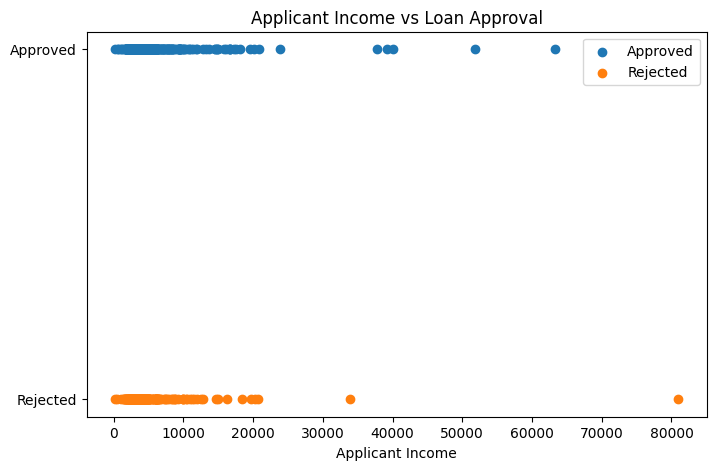

In [135]:
approved = loan_df[loan_df['Loan_Status'] == 'Y']
rejected = loan_df[loan_df['Loan_Status'] == 'N']

plt.figure(figsize=(8,5))

plt.scatter(
    approved['ApplicantIncome'],
    [1]*len(approved),
    label='Approved'
)

plt.scatter(
    rejected['ApplicantIncome'],
    [0]*len(rejected),
    label='Rejected'
)

plt.yticks([0,1], ['Rejected','Approved'])
plt.xlabel("Applicant Income")
plt.title("Applicant Income vs Loan Approval")
plt.legend()
plt.show()

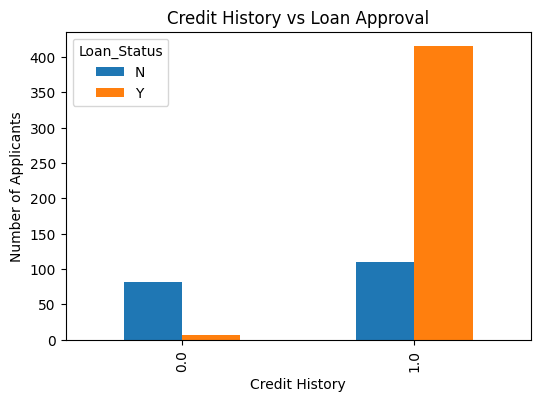

In [136]:
credit = pd.crosstab(
    loan_df['Credit_History'],
    loan_df['Loan_Status']
)

credit.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Credit History vs Loan Approval")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.show()

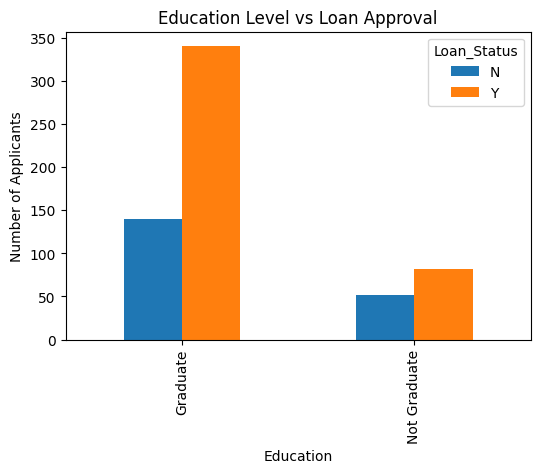

In [137]:
education = pd.crosstab(
    loan_df['Education'],
    loan_df['Loan_Status']
)

education.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Education Level vs Loan Approval")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")
plt.show()

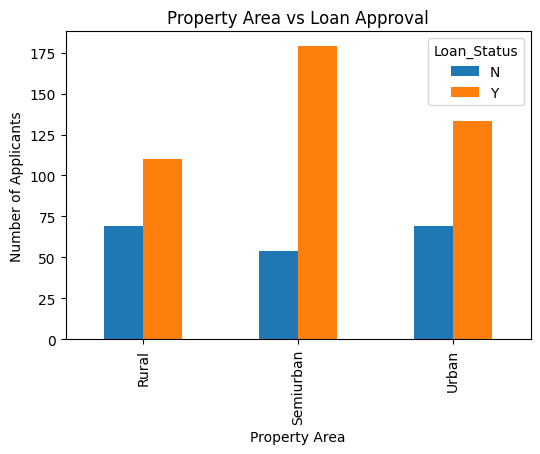

In [138]:
property_area = pd.crosstab(
    loan_df['Property_Area'],
    loan_df['Loan_Status']
)

property_area.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Property Area vs Loan Approval")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")
plt.show()

Answer the following:

1. Which feature appears most influential in loan approval?    
~ Credit History
2. What patterns can be observed from the visualizations?

~ The visualizations suggest that credit history is the strongest factor influencing loan approval, while applicant income, education level, and property area also contribute to the decision. Loan approval depends on a combination of these factors rather than a single attribute.



Question 4. Split the dataset into training and testing sets (80:20).
Train the following models:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

For each model:
Calculate Accuracy, Precision, Recall, F1 Score. Present the results in a comparison table.


In [139]:

le = LabelEncoder()

for col in categorical_cols:
    loan_df[col] = le.fit_transform(loan_df[col])

loan_df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [140]:
X = loan_df.drop('Loan_Status', axis=1)

y = loan_df['Loan_Status']

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (614, 12)
Target Variable Shape: (614,)


In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 491
Testing records: 123


In [142]:
lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, max_iter=1000)
)

lr_model.fit(X_train, y_train)

lr_train_preds = lr_model.predict(X_train)
lr_test_preds = lr_model.predict(X_test)

lr_train_acc = accuracy_score(y_train, lr_train_preds)
lr_test_acc = accuracy_score(y_test, lr_test_preds)

print("Training Accuracy:", lr_train_acc)
print("Testing Accuracy:", lr_test_acc)

Training Accuracy: 0.8187372708757638
Testing Accuracy: 0.7886178861788617


In [143]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.6910569105691057


In [144]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_train_preds = rf_model.predict(X_train)
rf_test_preds = rf_model.predict(X_test)

rf_train_acc = accuracy_score(y_train, rf_train_preds)
rf_test_acc = accuracy_score(y_test, rf_test_preds)

print("Training Accuracy:", rf_train_acc)
print("Testing Accuracy:", rf_test_acc)


Training Accuracy: 1.0
Testing Accuracy: 0.7804878048780488


In [155]:
models = {
    "Decision Tree": model,
    "Random Forest": rf_model,
    "Logistic Regression": lr_model
}

# Print the report for each model
for name, clf in models.items():
    print(f"\n {name} EVALUATION")
    preds = clf.predict(X_test)
    print(classification_report(y_test, preds, zero_division=0))


 Decision Tree EVALUATION
              precision    recall  f1-score   support

           0       0.56      0.51      0.54        43
           1       0.75      0.79      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.65       123
weighted avg       0.69      0.69      0.69       123


 Random Forest EVALUATION
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123


 Logistic Regression EVALUATION
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.

Question 5. Based on the performance metrics:
1. Identify the best-performing model. ~ Logistic Regression
2. Justify your choice using evaluation metrics. ~ High Accuracy and precision
3. Discuss the strengths and limitations of each model.

~Logistic Regression is simple, fast, and interpretable but struggles with non-linear patterns.

Decision Trees handle complex relationships and are easy to visualize but may overfit.

 Random Forest improves accuracy and reduces overfitting by combining multiple trees, though it is computationally expensive and less interpretable than the other models.

Question 6. Apply Stratified 5-Fold Cross Validation to all three models.
Tasks:
1. Compute accuracy for each fold.
2. Calculate mean accuracy and standard deviation.
3. Compare cross-validation results with the train-test split results.


In [146]:
cv_model = DecisionTreeClassifier(max_depth=3, random_state=42)

cv_scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)
print("Average Cross Validation Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.81300813 0.76422764 0.7804878  0.85365854 0.82786885]
Average Cross Validation Accuracy: 0.8078501932560309


1. Why is Stratified K-Fold preferred for this dataset?
2. Which model shows the most consistent performance?




*  ANS1:  Stratified K-Fold is preferred because it preserves the same proportion of loan approval classes in every fold. This ensures each training and testing split represents the original dataset, reducing bias and providing a more reliable evaluation, especially when the target variable is imbalanced.
*   ANS2: The Random Forest model generally shows the most consistent performance because it combines predictions from multiple decision trees, reducing overfitting and improving stability. It usually achieves higher and more reliable accuracy across different data splits compared to Logistic Regression and a single Decision Tree.



Question 7. Perform hyperparameter tuning on the Random Forest Classifier using GridSearchCV. Tune the following parameters:
n_estimators = [50, 100, 200]

max_depth = [3, 5, 10]

min_samples_split = [2, 5, 10]

Tasks:
1. Identify the best parameter combination.
2. Report the best cross-validation score.
3. Evaluate the tuned model on the test set.

Compare:

*   Model performance before tuning
*   Model performance after tuning

In [147]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X, y)
print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV Accuracy:", rf_grid.best_score_)


Best Random Forest Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best Random Forest CV Accuracy: 0.8111022257763562


In [152]:
best_rf = rf_grid.best_estimator_
y_pred_after = best_rf.predict(X_test)

print("After Tuning")

print("Accuracy :", accuracy_score(y_test, y_pred_after))
print("Precision:", precision_score(y_test, y_pred_after))
print("Recall   :", recall_score(y_test, y_pred_after))
print("F1 Score :", f1_score(y_test, y_pred_after))

After Tuning
Accuracy : 0.7967479674796748
Precision: 0.7619047619047619
Recall   : 1.0
F1 Score : 0.8648648648648649


Question 8. Train three Decision Tree models using:

max_depth = 2

max_depth = 5

max_depth = 15

For each model:
1. Compute training accuracy.
2. Compute testing accuracy.
3. Compare the results.


In [163]:
depths = [2, 5, 15]
results = []

for depth in depths:
    dt_model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    dt_model.fit(X_train, y_train)


    train_pred = dt_model.predict(X_train)
    test_pred = dt_model.predict(X_test)


    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

      # Difference between train and test accuracy
    gap = train_acc - test_acc

    if gap < 0.05:
        finding = "Underfitting" if train_acc < 0.85 else "Good Balance"
    elif gap < 0.10:
        finding = "Slight Overfitting"
    else:
        finding = "Overfitting"

    results.append([depth, train_acc, test_acc, finding])

comparison_df = pd.DataFrame(
    results,
    columns=["Max Depth", "Training Accuracy", "Testing Accuracy", "Finding"]
)

comparison_df



,Max Depth,Training Accuracy,Testing Accuracy,Finding
0,2,0.820774,0.788618,Underfitting
1,5,0.855397,0.747967,Overfitting
2,15,0.995927,0.699187,Overfitting


1. Which model exhibits underfitting?
2. Which model exhibits overfitting?
3. Which model provides the best balance between bias and variance?

Present your findings in a table.


In [164]:
comparison_df

,Max Depth,Training Accuracy,Testing Accuracy,Finding
0,2,0.820774,0.788618,Underfitting
1,5,0.855397,0.747967,Overfitting
2,15,0.995927,0.699187,Overfitting




*  The Decision Tree with max_depth = 2 achieved the highest testing accuracy (78.86) and the smallest gap between training and testing accuracy, indicating the best generalization performance.


*   The Decision Tree with max_depth = 15 showed overfitting, with very high training accuracy (99.59%) but much lower testing accuracy (69.92%), while max_depth = 5 exhibited slight overfitting.



